Types of Test:

* 1 sample test
    * We have 1 group of data
    * Eg: stock returns vs a fixed value
* 2 sample test
    * We have 2 groups of data
    * Eg: C vs T tests.



* 2 sided test:

    * H0 : $\mu_1$ = $\mu_2$

    * H1 : $\mu_1$ $\ne$ $\mu_2$

* 1 sided test:

    * H0 : $\mu_1$ $\le$ $\mu_2$

    * H1 : $\mu_1$ > $\mu_2$



Statistical Significance:

* We can't simply compare averages of two groups in an experiment. By the nature of numbers, the averages will always be different. Simply saying that avg1 > avg2 doesn't imply group 1 > group 2.

* We need to find out whether the difference is statistically significant.

* Factors affecting significance:
    * Effect Size (difference in means)
    * Variance
    * Sample size

*  1 sample test:
    * statsmodels: ztest(x)
    * scipy: ttest_1samp(x)

* 2 sample test:
    * statsmodels: ztest(x1, x2)
    * scipy: ttest_ind(x1,x2)

Interpretation of p-value:
* p-value is the probability of observing a result as extreme or more extreme than what was observed, assuming the null hypothesis is true.
* The significance threshold is called maximum allowed probability of false alarm. 
* If p-value < significance threshold, then we reject Null Hypothesis.

# Z-Test

* Assuming our data is normally distributed.

## 1 sample test:

H0 : $\mu$ = $\mu_0$

H1 : $\mu$ $\ne$ $\mu_0$

Rewriting H0:

$$H_0 : \hat \mu = N(\mu_0, \frac{\sigma^2}{N})$$

We can standardize this:

$$H0: z = \frac{\hat \mu - \mu_0}{\sigma \sqrt N} = N(0,1)$$

This is called z-statistic.


Now we simply need to compare z with significance threshold.


## 2 sample Z test:

* Calculate Z statistic
* Get the lower and upper bounds
* Evaluate significance.

Z - statistic:

$$z = \frac{\mu_1 - \mu_2 - \mu_0}{\sqrt {\frac{\sigma_1^2}{N_1} + \frac{\sigma_2^2}{N_2}}}$$

In [1]:
import numpy as np
from scipy.stats import norm
from statsmodels.stats.weightstats import ztest

# 1 Sample Test

In [2]:
N = 1000
mu = 5
sigma = 1
x = norm.rvs(size=N, loc=mu, scale=sigma)

len(x)

1000

In [3]:
# two sided one sample Z test using sm
ztest(x)

(np.float64(157.30972134831975), np.float64(0.0))

In [4]:
#manually doing Z test
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)

z = (mu_hat - 0)/(sigma_hat/np.sqrt(N))

p_right = 1 - norm.cdf(np.abs(z)) # use norm.sf in practice

p_left = norm.cdf(-np.abs(z))

p = p_right + p_left

z, p

(np.float64(157.30972134831975), np.float64(0.0))

In [5]:
# one sided test

ztest(x, alternative='larger')

(np.float64(157.30972134831975), np.float64(0.0))

In [6]:
z = (mu_hat - 0)/(sigma_hat/np.sqrt(N))
p = 1-norm.cdf(np.abs(z))
z, p

(np.float64(157.30972134831975), np.float64(0.0))

In [7]:
# null under a different reference value
mu0 = 0.2

ztest(x, value=mu0)

(np.float64(150.95076856421164), np.float64(0.0))

In [8]:
#manually doing Z test
mu_hat = x.mean()
sigma_hat = x.std(ddof=1)

z = (mu_hat - mu0)/(sigma_hat/np.sqrt(N))

p_right = 1 - norm.cdf(np.abs(z)) # use norm.sf in practice

p_left = norm.cdf(-np.abs(z))

p = p_right + p_left

z, p

(np.float64(150.95076856421164), np.float64(0.0))

# 2 Sample Test

In [9]:
N0 = 100
mu0 = 0.2
sigma_0 = 1
x0 = norm.rvs(size=N0, loc=mu0, scale=sigma_0)

In [10]:
N1 = 100
mu1 = 0.5
sigma_1 = 1
x1 = norm.rvs(size=N1, loc=mu1, scale=sigma_1)

In [11]:
ztest(x0, x1)

(np.float64(-0.7434411261251178), np.float64(0.457214653084977))

In [12]:
mu_hat0 = np.mean(x0)
mu_hat1 = np.mean(x1)

s2_hat0 = x0.var(ddof=1)
s2_hat1 = x1.var(ddof=1)
s_hat = np.sqrt(s2_hat0/N0 + s2_hat1/N1)

z = (mu_hat0 - mu_hat1-0)/s_hat

p_right = 1 - norm.cdf(np.abs(z))
p_left = norm.cdf(-np.abs(z))
p = p_right + p_left

z, p

(np.float64(-0.7434411261251178), np.float64(0.457214653084977))

# Applying Z test on titanic

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Option 1: Load via Seaborn (clean and immediate)
titanic = sns.load_dataset('titanic')


titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [14]:
x1 = titanic.loc[titanic['survived'] == 1]['fare'].dropna().to_numpy()
x2 = titanic.loc[titanic['survived'] == 0]['fare'].dropna().to_numpy()

In [15]:
x1.shape, x2.shape

((342,), (549,))

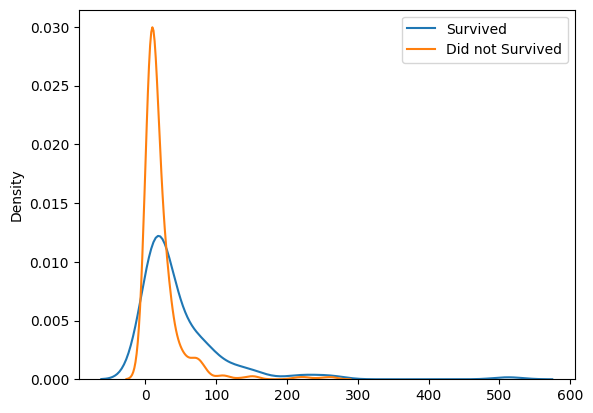

In [16]:
sns.kdeplot(x1, label='Survived')
sns.kdeplot(x2, label='Did not Survived')
plt.legend();

In [17]:
x1.mean(), x2.mean()

(np.float64(48.39540760233918), np.float64(22.117886885245902))

* Question: is the fare for survivors significantly different from non-survivors

In [18]:
ztest(x1, x2)

(np.float64(7.939191660871055), np.float64(2.0350311035739884e-15))

Inference: Null hypothesis rejected

# A/B Testing on Ad Data

In [19]:
import pandas as pd

df = pd.read_csv("advertisement_clicks.csv")
df.head()

,advertisement_id,action
0,B,1
1,B,1
2,A,0
3,B,0
4,A,1


In [20]:
clicks_a = df.loc[df['advertisement_id'] == 'A', 'action']
clicks_b = df.loc[df['advertisement_id'] == 'B', 'action']

In [21]:
from statsmodels.stats.weightstats import ztest

ztest(clicks_a, clicks_b)

(np.float64(-3.2211732138019786), np.float64(0.0012766696301529544))